# Titanic Survival — Exploratory Data Analysis

## What this project is
Analysis of 891 Titanic passengers to understand what factors
were linked to survival. My first data science project.

## Key findings
- Overall survival rate: 38.4%
- Women survived at 74.2%, men at 18.9% — nearly 4x difference
- 1st class survival: 63% vs 3rd class: 24%
- Fare and class both positively correlate with survival
- Children under 10 had higher survival rates than adults

## Tools
Python · Pandas · Matplotlib · Seaborn · Google Colab

## Dataset
Kaggle Titanic Competition — train.csv (891 rows, 12 columns)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print ("Libraries loaded! ")

Libraries loaded! 


In [8]:
# load the data
df = pd.read_csv('train.csv')
print(f"Dataset loaded: {df.shape[0]} passangers, {df.shape[1]} columns")

Dataset loaded: 891 passangers, 12 columns


In [ ]:
# look at the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Get a summary of every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
#see basic statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# check exactly which clolumns have missing data
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [12]:
# fix the missinng Age values
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f"Missing ages after fix: {df['Age'].isnull().sum()}")

Missing ages after fix: 0


/tmp/ipykernel_2206/3774357231.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


Overall survival rate: 38.4%


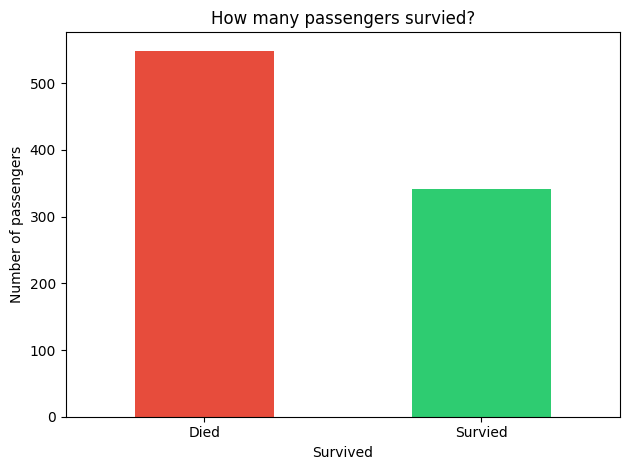

In [16]:
# First real queition: who survived?
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

df['Survived'].value_counts().plot(kind= 'bar', color=['#e74c3c','#2ecc71'])
plt.xticks([0,1],['Died','Survied'], rotation=0)
plt.title('How many passengers survied?')
plt.ylabel('Number of passengers')
plt.tight_layout()
plt.show()

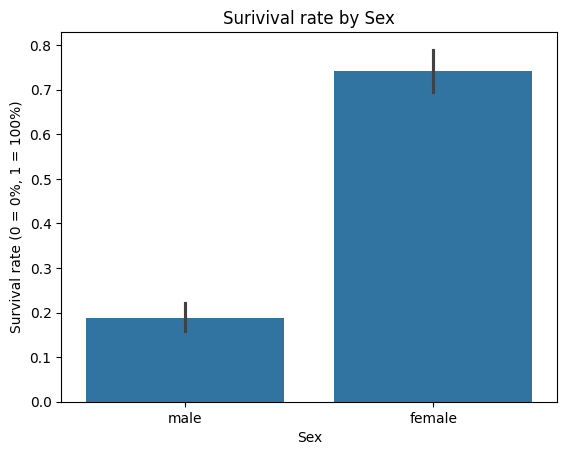

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [17]:
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Surivival rate by Sex')
plt.ylabel('Survival rate (0 = 0%, 1 = 100%)')
plt.show()


# Print the exact numbers
print(df.groupby('Sex')['Survived'].mean())

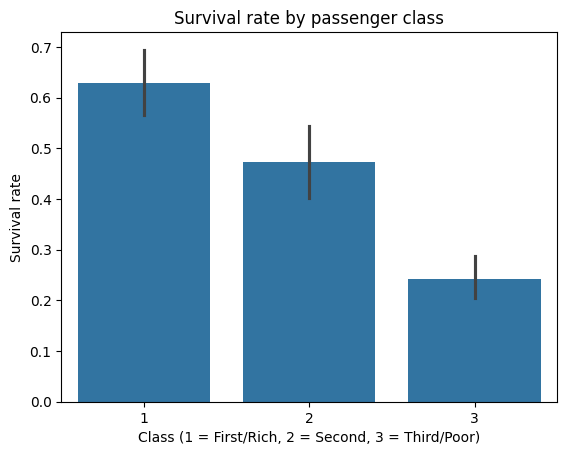

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [18]:
# Survival by passenger class - did money matter?
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.xlabel('Class (1 = First/Rich, 2 = Second, 3 = Third/Poor)')
plt.ylabel('Survival rate')
plt.show()

# Print exact numbers
print(df.groupby('Pclass')['Survived'].mean())

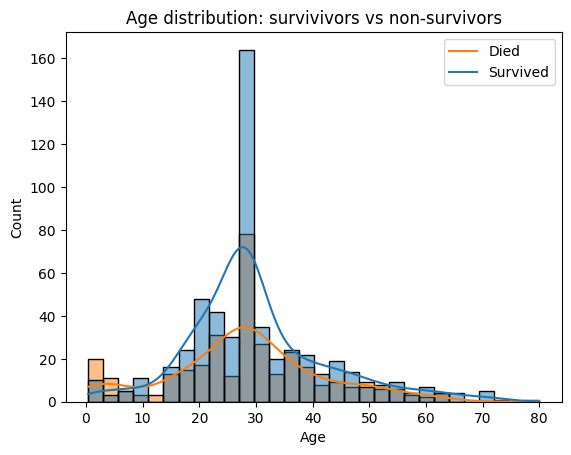

In [19]:
# Age distribution - did age affect survival?
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age distribution: survivivors vs non-survivors')
plt.xlabel('Age')
plt.legend(['Died', 'Survived'])
plt.show()

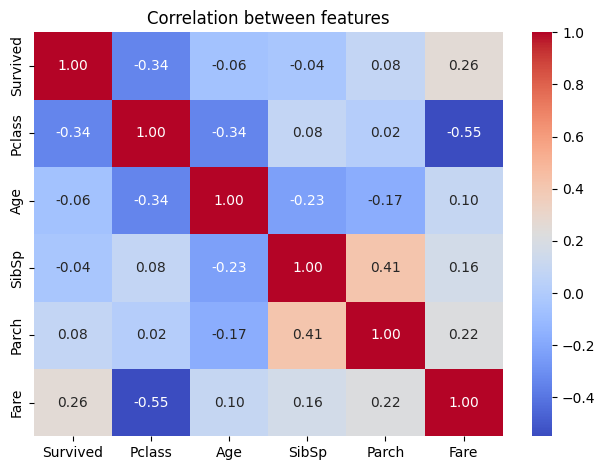

In [22]:
# Correlation heatmap - all relationships at once
corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between features')
plt.tight_layout()
plt.show()